# `Mu3e Data Analysis`
This notebook explores the ROOT file: `mu3e_sort_run0001000.root`

In [3]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

%matplotlib inline

## `open ROOT file`

In [4]:
# Open the ROOT file
file = uproot.open("data/conf14/mu3e_sort_run0001001.root")

# List all keys (trees) in the file
print("Top-level ROOT objects:")
for key, cls in file.classnames().items():
    #if "TTree" in cls:
    print(f"  {key}   ({cls})")

Top-level ROOT objects:
  alignment;1   (TDirectory)
  alignment/target;1   (TDirectory)
  alignment/target/TargetCenterX;1   (TVectorT<double>)
  alignment/target/TargetCenterY;1   (TVectorT<double>)
  alignment/target/TargetCenterZ;1   (TVectorT<double>)
  alignment/target/TargetType;1   (TVectorT<double>)
  alignment/target/TargetLength;1   (TVectorT<double>)
  alignment/target/TargetRadius;1   (TVectorT<double>)
  alignment/target/TargetThickness1;1   (TVectorT<double>)
  alignment/target/TargetThickness2;1   (TVectorT<double>)
  alignment/sensors;2   (TTree)
  alignment/sensors;1   (TTree)
  alignment/tiles;2   (TTree)
  alignment/tiles;1   (TTree)
  alignment/fibres;2   (TTree)
  alignment/fibres;1   (TTree)
  alignment/mppcs;2   (TTree)
  alignment/mppcs;1   (TTree)
  mu3e_mchits;2   (TTree)
  mu3e_mchits;1   (TTree)
  mu3e_mc_tracks;2   (TTree)
  mu3e_mc_tracks;1   (TTree)
  stat;1   (TDirectory)
  stat/muonstat;1   (TObjString)
  stat/Pixeldose;1   (TDirectory)
  stat/Pixeldos

## `explore tree structure`

In [5]:
# picking mu3e events tree
mu3e = file["mu3e"]

print(f"\nExploring tree: mu3e")
print(f"Number of entries: {mu3e.num_entries}")  # works now
print("\nBranches:")
for branch_name, branch in mu3e.items():
    print(f"  {branch_name}: {branch.typename}")


Exploring tree: mu3e
Number of entries: 50000

Branches:
  Nhit: int32_t
  hit_pixelid: std::vector<uint32_t>
  hit_timestamp: std::vector<uint32_t>
  hit_tot: std::vector<int32_t>
  hit_mc_i: std::vector<int32_t>
  hit_mc_n: std::vector<int32_t>
  Nfibrehit: int32_t
  fibrehit_fibre: std::vector<uint32_t>
  fibrehit_time: std::vector<double>
  fibrehit_mppc_hitsL: std::vector<int32_t>
  fibrehit_mppc_hitsR: std::vector<int32_t>
  fibrehit_ampL: std::vector<int32_t>
  fibrehit_ampR: std::vector<int32_t>
  fibrehit_mc_i: std::vector<int32_t>
  fibrehit_mc_n: std::vector<int32_t>
  Nfibredetectorhit: int32_t
  fibredetectorhit_time: std::vector<double>
  fibredetectorhit_secondary: std::vector<int32_t>
  fibredetectorhit_ribbon: std::vector<int32_t>
  fibredetectorhit_mc_i: std::vector<int32_t>
  fibredetectorhit_mc_n: std::vector<int32_t>
  Nfibremppc: int32_t
  fibremppc_mppc: std::vector<uint32_t>
  fibremppc_col: std::vector<int32_t>
  fibremppc_timestamp: std::vector<uint32_t>
  fi

In [6]:
mu3e_mchits = file["mu3e_mchits"]

print(f"\nExploring tree: mu3e_mchits")
print(f"Number of entries: {mu3e_mchits.num_entries}")  # works now
print("\nBranches:")
for branch_name, branch in mu3e_mchits.items():
    print(f"  {branch_name}: {branch.typename}")


Exploring tree: mu3e_mchits
Number of entries: 28213983

Branches:
  det: int32_t
  tid: int32_t
  pdg: int32_t
  hid: int32_t
  hid_g: int32_t
  edep: double
  time: double
  mc_track: unknown
  x: double
  y: double
  z: double
  px: double
  py: double
  pz: double
  e: double


In [7]:
mu3e_mc_tracks = file["mu3e_mc_tracks"]

print(f"\nExploring tree: mu3e_mc_tracks")
print(f"Number of entries: {mu3e_mc_tracks.num_entries}")  # works now
print("\nBranches:")
for branch_name, branch in mu3e_mc_tracks.items():
    print(f"  {branch_name}: {branch.typename}")


Exploring tree: mu3e_mc_tracks
Number of entries: 2113896

Branches:
  tid: int64_t
  mother: int64_t
  pdg: int32_t
  type: int32_t
  frameId: int32_t
  vx: double
  vy: double
  vz: double
  vt: double
  px: double
  py: double
  pz: double
  e: double
  weight: double


## `reading a single event`

In [15]:
mchits = mu3e_mchits.arrays(library='ak')

In [21]:
mchits_df = ak.to_pandas(mchits)

In [24]:
mchits_df['eventID'] = -1

,det,tid,pdg,hid,hid_g,edep,time,x,y,z,px,py,pz,e
entry,,,,,,,,,,,,,,
0,90,9,-13,0,0,0.000000,1.886190e+01,3.490949,-0.737346,-40.662215,0.000000,0.000000,0.000000,105.658372
1,90,14,-13,0,0,0.000000,7.178848e+01,2.980457,11.167601,19.517566,-0.000000,0.000000,0.000000,105.658372
2,10,363,-11,11,0,0.018330,4.287520e+02,16.346942,18.197498,-59.783616,4.967941,27.866118,-3.860695,28.572138
3,10,363,-11,1,0,0.028919,4.267213e+02,13.111014,19.537864,-21.029475,5.800282,42.262263,-0.028216,42.661505
4,10,118,-11,1,0,0.036084,4.840208e+02,-20.532436,10.709903,53.023941,-17.651426,12.089898,27.335290,34.716245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28213978,30,36152145,22,30,0,0.000288,1.282642e+07,42.460982,42.984535,488.115828,-0.000497,-0.000165,0.009897,0.009911
28213979,30,36152157,11,46,0,0.009623,1.282642e+07,42.234031,42.909250,492.634709,0.006002,0.099090,0.008519,0.520622
28213980,30,36149365,-11,6,2,0.168904,1.282642e+07,38.162719,49.286752,446.557206,-1.116358,-3.224215,13.364450,13.802589


In [8]:
hit_ids_by_event = mu3e['hit_mc_i'].array(library='np')
flatten_hit_ids = np.concatenate(hit_ids_by_event)
event_ids = np.concatenate([np.full(len(arr), i) for i, arr in enumerate(hit_ids_by_event)])

In [9]:
len(flatten_hit_ids)

2941780

In [22]:
event1 = mu3e.arrays(entry_start=1, entry_stop=2)
print("number of hits in event = ", len(ak.flatten(event1["hit_mc_i"])))
print("indices of corresponding hits in mu3e_mchits = ", event1["hit_mc_i"])

number of hits in event =  11
indices of corresponding hits in mu3e_mchits =  [[5817, 5819, 5820, 5821, 5823, 5824, 5825, 5826, 5828, 5829, 5830]]


## `sorting hits by event`

In [9]:
file_path = "data/conf14/mu3e_sort_run0001000.root"
file = uproot.open("data/conf14/mu3e_sort_run0001000.root")

events_tree = file["mu3e"]
hits_tree = file["mu3e_mchits"]

events = events_tree.arrays("hit_mc_i", library="ak")
hits = hits_tree.arrays(library="ak")

KeyboardInterrupt: 

In [18]:
tracks = file['mu3e_mc_tracks'].arrays(library='ak')

In [35]:
len(tracks) / len(events)

42.27952

### `unsorted`

In [8]:
ordered_events_list = []
for i in tqdm(range(len(events["hit_mc_i"]))):
    event = hits[events["hit_mc_i"][i]]
    
    sorted_indices = np.argsort(event["tid"])
    sorted_event = event[sorted_indices]
    
    ordered_events_list.append(sorted_event)

100%|██████████| 50000/50000 [01:11<00:00, 698.86it/s]


In [9]:
print(ordered_events_list[0]['x'])

[-22.2, -28.3, -64, -72.6, -68.9, -55.8, ... 20.3, -80.1, -17.4, -15.2, -25.3, -51.3]


### `event dictionary version`

In [9]:
ordered_events_vectorised = []
for i in tqdm(range(len(events["hit_mc_i"]))):
    event = hits[events["hit_mc_i"][i]]
    if len(event) == 0:
        continue
        
    track_id_array = np.array(event["tid"])
    sorted_idx = np.argsort(track_id_array)
    event_sorted = event[sorted_idx]
    track_id_sorted = track_id_array[sorted_idx]
    
    change_indices = np.flatnonzero(np.diff(track_id_sorted)) + 1
    
    per_track_hits = np.split(event_sorted, change_indices)
    unique_tids = track_id_sorted[np.r_[0, change_indices]]
    
    hit_tracks = {tid: hits for tid, hits in zip(unique_tids, per_track_hits)}
    
    ordered_events_vectorised.append(hit_tracks)

100%|██████████| 50000/50000 [02:45<00:00, 302.24it/s]


In [197]:
ordered_events = []
for i in tqdm(range(len(events["hit_mc_i"]))):
    event = hits[events["hit_mc_i"][i]]
    track_ids = np.unique(event["tid"])
    
    hit_tracks = {}
    for track_id in track_ids:
        mask = event["tid"] == track_id
        hit_tracks[track_id] = event[mask]
        
    ordered_events.append(hit_tracks)

100%|██████████| 50000/50000 [08:06<00:00, 102.68it/s]


In [5]:
print(ak.concatenate([ordered_events_vectorised[0][key]['x'] for key in ordered_events_vectorised[0].keys()]))
print(ak.concatenate([ordered_events_vectorised[0][key]['y'] for key in ordered_events_vectorised[0].keys()]))
print(ak.concatenate([ordered_events_vectorised[0][key]['z'] for key in ordered_events_vectorised[0].keys()]))

[-22.2, -64, -72.6, -28.3, -68.9, -55.8, ... -80.1, 13.4, -15.2, -51.3, -17.4, -25.3]
[-6.63, -33.7, -44.2, -8.65, -21.7, -45.7, ... 19.4, -18.7, -51.4, -18.3, -17.9]
[4.06, -29.8, -38.7, -0.382, -129, -126, ... 158, -31.8, 31.7, -109, 26.7, 7.99]


## `plot event function`

In [10]:
def plot_event(event):
    """
    Plot hit positions for a single event.
    
    Parameters:
    -----------
    event : awkward array
        Single event data containing hit position information
    """
    # Extract hit positions (adjust field names based on your data structure)
    x = event['x']
    y = event['y']
    z = event['z']
    
    # Create figure with subplots
    fig, axes = plt.subplots(1, 3, figsize=(20,6.5))
    
    # XY projection
    axes[0].scatter(x, y, alpha=0.8, s=10)
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('y')
    axes[0].set_title('XY Projection')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(-100,100)
    axes[0].set_ylim(-100,100)
    
    # XZ projection
    axes[1].scatter(z, x, alpha=0.8, s=10)
    axes[1].set_xlabel('z')
    axes[1].set_ylabel('x')
    axes[1].set_title('XZ Projection')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(-100,100)

    
    # YZ projection
    axes[2].scatter(z, y, alpha=0.8, s=10)
    axes[2].set_xlabel('z')
    axes[2].set_ylabel('y')
    axes[2].set_title('YZ Projection')
    axes[2].grid(True, alpha=0.3)
    axes[2].set_ylim(-100,100)

    
    plt.tight_layout()
    plt.show()
    
    print(f"Number of hits: {len(x)}")

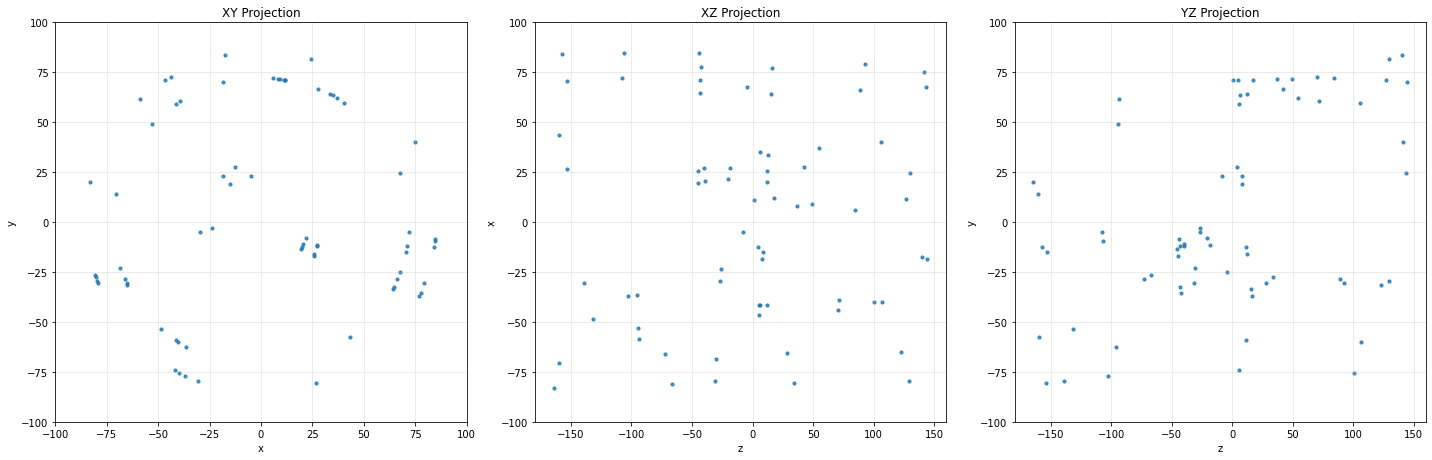

Number of hits: 69


In [11]:
event = ordered_events_list[42234]
plot_event(event)

### `event dictionary version`

In [259]:
def plot_event_dict(event):
    """
    Plot hit positions for a single event.
    
    Parameters:
    -----------
    event : awkward array
        Single event data containing hit position information
    """
    # Extract hit positions (adjust field names based on your data structure)
    x = ak.concatenate([event[key]['x'] for key in event.keys()])
    y = ak.concatenate([event[key]['y'] for key in event.keys()])
    z = ak.concatenate([event[key]['z'] for key in event.keys()])
    
    # Create figure with subplots
    fig, axes = plt.subplots(1, 3, figsize=(20,6.5))
    
    # XY projection
    axes[0].scatter(x, y, alpha=0.8, s=10)
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('y')
    axes[0].set_title('XY Projection')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(-100,100)
    axes[0].set_ylim(-100,100)
    
    # XZ projection
    axes[1].scatter(z, x, alpha=0.8, s=10)
    axes[1].set_xlabel('z')
    axes[1].set_ylabel('x')
    axes[1].set_title('XZ Projection')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(-100,100)

    
    # YZ projection
    axes[2].scatter(z, y, alpha=0.8, s=10)
    axes[2].set_xlabel('z')
    axes[2].set_ylabel('y')
    axes[2].set_title('YZ Projection')
    axes[2].grid(True, alpha=0.3)
    axes[2].set_ylim(-100,100)

    
    plt.tight_layout()
    plt.show()
    
    print(f"Number of hits: {len(x)}")

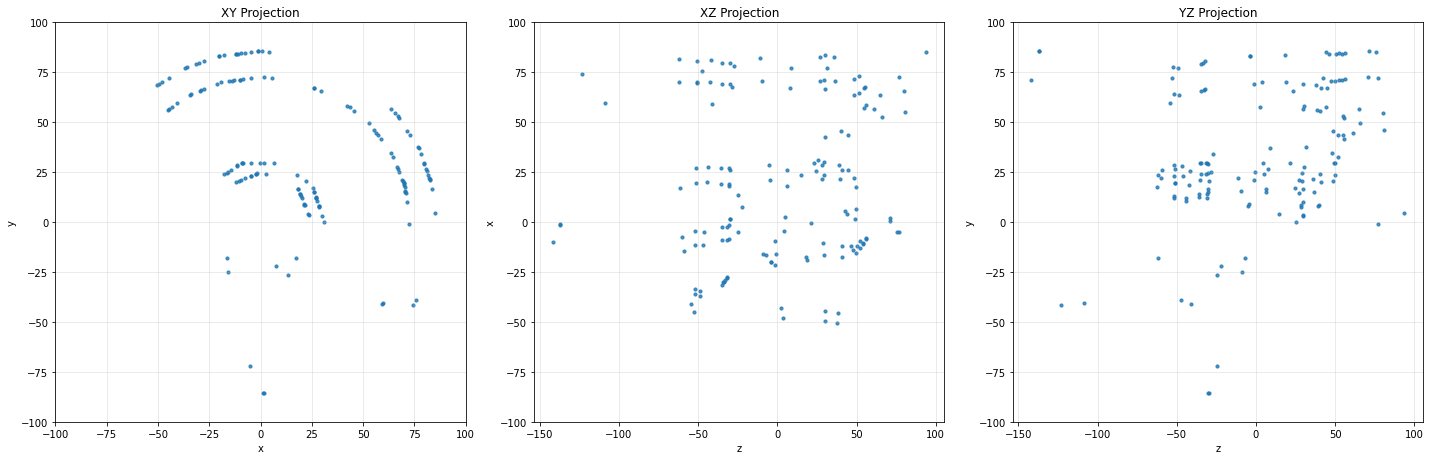

Number of hits: 148


In [260]:
event = ordered_events[2]
plot_event_dict(event)

## `data preparation`
convert into parquet file - this will be input to dataloader

In [1]:
import pandas as pd
from pathlib import Path

In [2]:
def is_valid_file(path):
    path = Path(path)
    return path.is_file() and path.stat().st_size > 0

In [5]:
in_dir = "/home/xzcapnai/hepattn/hepattn/src/hepattn/experiments/mu3e/data/conf14"